In [1]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import xarray as xr
from ellen_fxns import get_oisst_flag
import datetime

In [2]:
mhw_dates = pd.read_csv('../../MHW_list.csv')
mhw_dates

,name,date_start,date_end,lon0,lon1,lat0,lat1
0,Med2003,2003-06-01,2003-09-14,-5,20,36,46
1,Beng2001,2001-03-24,2001-05-25,10,20,-35,-15
2,WA2011,2011-01-09,2011-06-27,108,118,-35,-22
3,NWA2012,2012-06-13,2013-03-13,-72,-60,38,45
4,WSA2014,2014-01-17,2014-08-03,-52,-40,-42,-30
5,ECS2016,2016-09-29,2017-02-26,120,132,28,38
6,AL2016,2016-01-01,2017-01-12,-175,-150,52,62
7,NA2016,2016-02-09,2016-08-23,120,135,-20,-10
8,NEP2015,2015-01-05,2016-02-03,-145,-125,38,52
9,Tas2017,2017-09-26,2018-04-10,145,155,-46,-38


In [3]:
mhw = 'NA 2023'
lon0, lon1, lat0, lat1 = mhw_dates.loc[(mhw_dates.loc[:,'name']==mhw), ['lon0','lon1','lat0','lat1']].values[0,:]
start_time, end_time = mhw_dates.loc[(mhw_dates.loc[:,'name']==mhw), ['date_start','date_end']].values[0,:]

In [4]:
delta_days = 365
time0 = np.datetime64(start_time) - datetime.timedelta(days=delta_days)
time1 = np.datetime64(end_time) + datetime.timedelta(days=delta_days)

# Depth filter
depth_min = 500

In [5]:
filter_coords_time = [
    ("JULD",">=",time0),("JULD","<=",time1),
    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
    ("PRES", "<", depth_min),]

In [6]:
# Setting up parquet schema
parquet_dir = '../../../shared/go-bgc-2026/data/CrocoLake/BGC_ARGO/'
BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

filter_coords_time = [("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                      ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                      ("JULD",">=",time0),("JULD","<=",time1),
                      ("PRES","<",depth_min),
                     ]

df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filter_coords_time)
df = df.read().to_pandas()

In [7]:
df = df.assign(MONTH = [pd.Timestamp(ti).month for ti in df.loc[:,'JULD'].values])
df = df.assign(YEAR = [pd.Timestamp(ti).year for ti in df.loc[:,'JULD'].values])

In [8]:
plist = ['MONTH','TEMP','YEAR','PLATFORM_NUMBER','CYCLE_NUMBER']

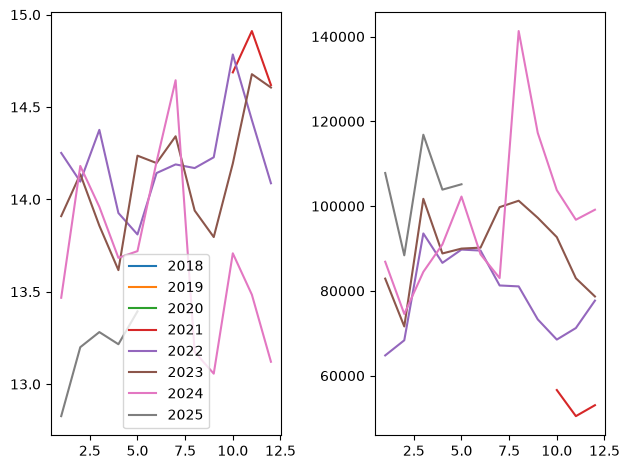

In [9]:
fig = plt.figure()
rr = 1; cc =2

ax1 = fig.add_subplot(rr, cc, 1)
ax2 = fig.add_subplot(rr, cc, 2)

# mean_df = df.loc[:,plist].groupby(by = ['PLATFORM_NUMBER','CYCLE_NUMBER']).mean() 

# for year in sorted(df.loc[:,'YEAR'].unique()):
for year in sorted(np.arange(2018, 2026)):
    ax1.plot(df.loc[df.loc[:,'YEAR']==year,plist].groupby(by = 'MONTH').mean().index.values, 
               df.loc[df.loc[:,'YEAR']==year,plist].groupby('MONTH').mean().loc[:,'TEMP'],
               label = year)

    ax2.plot(df.loc[df.loc[:,'YEAR']==year,plist].groupby('MONTH').count().index.values, 
               df.loc[df.loc[:,'YEAR']==year,plist].groupby('MONTH').count().loc[:,'TEMP'],
               label = year)
ax1.legend()

fig.tight_layout()
# plt.scatter(df.loc[df.loc[:,'YEAR']!=2023,plist].groupby('MONTH').mean().index.values, 
#           df.loc[df.loc[:,'YEAR']!=2023,plist].groupby('MONTH').mean().loc[:,'TEMP'])

In [10]:
float_data = df.loc[:,['PLATFORM_NUMBER','CYCLE_NUMBER', 'LONGITUDE','LATITUDE','JULD']].groupby(by = ['PLATFORM_NUMBER','CYCLE_NUMBER']).mean()
float_data

LONGITUDE  LATITUDE  \
PLATFORM_NUMBER CYCLE_NUMBER                        
1902303         53             -17.2050   46.1840   
                54             -17.7010   45.6470   
                55             -18.1630   45.1450   
                56             -18.2600   44.8050   
                57             -17.9820   44.4290   
...                                 ...       ...   
7902226         11             -47.7739   27.4338   
                12             -47.5351   27.5882   
                13             -47.0855   27.3342   
                14             -46.9799   27.0138   
                15             -47.1754   26.7483   

                                                      JULD  
PLATFORM_NUMBER CYCLE_NUMBER                                
1902303         53           2021-10-08 06:29:42.000685568  
                54           2021-10-18 05:58:53.000620544  
                55           2021-10-28 06:32:53.000689920  
                56           2021-11-07 05:11:42.000552192  
                57           2021-11-17 03:52:51.000397312  
...                                                    ...  
7902226         11           2025-04-20 08:08:44.000869888  
                12           2025-04-30 10:44:35.001136640  
                13           2025-05-10 11:40:44.001238016  
                14           2025-05-20 13:33:21.001442816  
                15           2025-05-30 15:23:43.001642496  

[7020 rows x 3 columns]

In [12]:
# oisst_path = 's3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr'
# mhw_data = xr.open_zarr(oisst_path)
#mhw_data.close()
#XX, YY = np.meshgrid(mhw_data['lon'].values, mhw_data['lat'].values)

In [11]:
test_fxn = False

if test_fxn:
    all_float_data = df
    oisst_path = 's3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr'
    time_name = 'time'
    lon_name = 'lon'
    lat_name = 'lat'
    flag_name = 'mhw_mask'
    
    # Get all locations 
    float_data = all_float_data.loc[:,['PLATFORM_NUMBER','CYCLE_NUMBER', \
                                       'LONGITUDE','LATITUDE','JULD']].groupby(by = ['PLATFORM_NUMBER','CYCLE_NUMBER']).mean()

    float_wmo_cycle = float_data.index.values
    
    # Load OISST data
    # zarr
    print('Openining : '+oisst_path)
    if oisst_path.split('.')[-1] == 'zarr':
        mhw_data = xr.open_zarr(oisst_path)
    elif oisst_path.split('.')[-1] == '.nc':
        mhw_data = xr.open_dataset(oisst_path)
    
    mhw_data.close()
    
    # Make KDTree for nearest neighbor matchups based on MWH mask
    XX, YY = np.meshgrid(mhw_data[lon_name].values, mhw_data[lat_name].values)
    # xx: lon; yy: lat
    tree = KDTree(np.c_[XX.ravel(),YY.ravel()])
    
    all_mhw_flags = np.zeros(all_float_data.shape[0])*-999
    
    # Convert all float date-times to just date
    dates = np.array([pd.Timestamp(xi).date() for xi in float_data.loc[:,'JULD'].values], dtype='datetime64[D]')
    
    # Get unique dates
    unique_dates = np.unique(dates)
    
    # For each date...
    for di, match_date in enumerate(unique_dates):
    
        if di%100 == 0:
            print(di, ' out of', unique_dates.shape[0])
            
        # 1. Get MWH slice for that date
        mhw_i = np.where(mhw_data[time_name].values.astype('datetime64[D]') == match_date)[0]
    
        # If the date is in the data range,
        if mhw_i.shape[0] > 0:
    
            # Subset array
            # mhw_mask = mhw_data[flag_name].isel(**{time_name: mhw_i})
            
            # 2. Get all profile locations
            prof_inds = np.where(unique_dates == match_date)[0]

            if prof_inds.shape[0]==0:
                    print(match_date)

            # Convert longitude to 360
            lons = (((360 + (float_data.loc[:,'LONGITUDE'].values[prof_inds] % 360)) % 360))
            lats = float_data.loc[:,'LATITUDE'].values[prof_inds]

            # 3. Use nearest neighbor to get flag
            for ni in np.arange(prof_inds.shape[0]):
            
                # print(ni, lons[ni], lats[ni])
                dd, ii = tree.query([lons[ni], lats[ni]])
                ri, ci = np.unravel_index(ii, XX.shape)
    
                # Get index for expanded data
                wmo, cycle = float_wmo_cycle[prof_inds][ni]
                all_inds = all_float_data.loc[(all_float_data.loc[:,'PLATFORM_NUMBER']==wmo) & \
                    (all_float_data.loc[:,'CYCLE_NUMBER']==cycle),:].index.values
                
                # 4. Assign flags back to original shape
                output_value = mhw_data[flag_name].isel(**{time_name: mhw_i,lat_name: ri, lon_name: ci}).values[0]
                all_mhw_flags[all_inds] = output_value

        else:
            print(di)
    # Add flags to pandas data frame
    all_float_data = all_float_data.assign(**{flag_name: all_mhw_flags})

In [12]:
# df_flag = all_float_data

In [13]:
df_flag = get_oisst_flag(df)

Openining : s3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr


0  out of 1328


100  out of 1328


200  out of 1328


300  out of 1328


...

900  out of 1328


1000  out of 1328


1100  out of 1328


1200  out of 1328


1300  out of 1328


In [14]:
df_flag.loc[:,'mhw_mask'].unique()

array([0., 1.])

In [15]:
df_flag.loc[:,plist].groupby('PLATFORM_NUMBER').mean()

,MONTH,TEMP,YEAR,CYCLE_NUMBER
PLATFORM_NUMBER,,,,
1902303,6.277161,12.966476,2022.083751,81.98214
1902304,5.650732,12.217742,2022.050812,94.757166
1902380,6.122731,18.152336,2023.251438,61.982549
1902381,6.100878,16.394039,2023.250135,61.893134
1902382,6.152180,16.538548,2023.255016,62.410641
...,...,...,...,...
7901027,7.964925,6.694839,2024.241463,62.002057
7901036,4.057478,4.802599,2024.882405,61.996188
7901146,3.484771,15.192822,2025.000000,6.499646


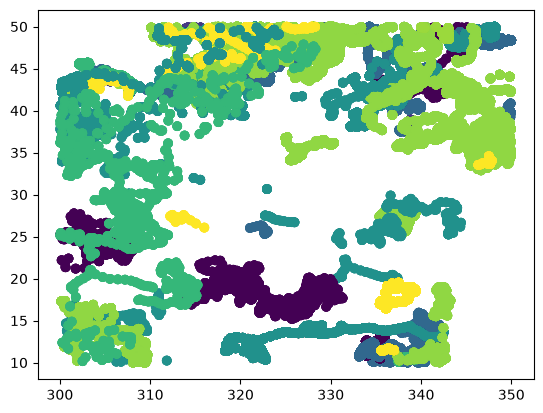

In [16]:
plt.scatter((((360 + (df_flag.loc[(df_flag.loc[:,'PRES']<10),'LONGITUDE'].values % 360)) % 360)), 
            df_flag.loc[(df_flag.loc[:,'PRES']<10),'LATITUDE'],
           c = df_flag.loc[(df_flag.loc[:,'PRES']<10),'PLATFORM_NUMBER'])

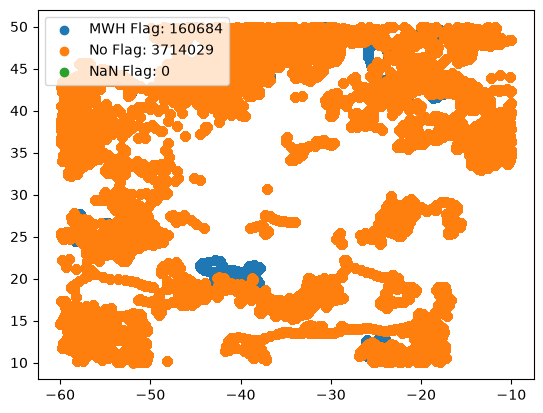

In [25]:
plt.figure()

plt.scatter(df_flag.loc[df_flag.loc[:,'mhw_mask']==1,'LONGITUDE'], 
            df_flag.loc[df_flag.loc[:,'mhw_mask']==1,'LATITUDE'],
           label = 'MWH Flag: '+str(df_flag.loc[df_flag.loc[:,'mhw_mask']==1,'LONGITUDE'].shape[0]))

plt.scatter(df_flag.loc[df_flag.loc[:,'mhw_mask']==0,'LONGITUDE'], 
            df_flag.loc[df_flag.loc[:,'mhw_mask']==0,'LATITUDE'],
           label = 'No Flag: '+str(df_flag.loc[df_flag.loc[:,'mhw_mask']==0,'LONGITUDE'].shape[0]))

plt.scatter(df_flag.loc[df_flag.loc[:,'mhw_mask'].isna(),'LONGITUDE'], 
            df_flag.loc[df_flag.loc[:,'mhw_mask'].isna(),'LATITUDE'],
           label = 'NaN Flag: '+str(df_flag.loc[df_flag.loc[:,'mhw_mask'].isna(),'LONGITUDE'].shape[0]))

plt.legend(loc = 'upper left')

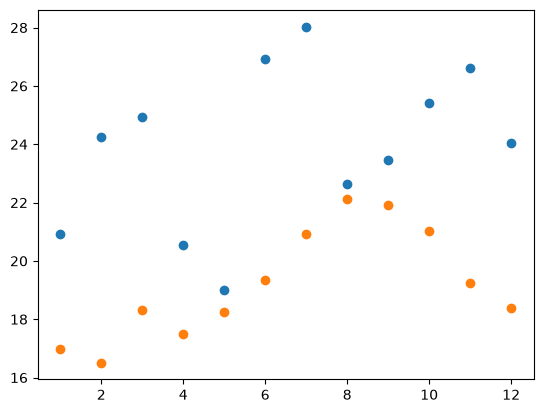

In [26]:
plt.scatter(df_flag.loc[(df_flag.loc[:,'mhw_mask']==1) & (df_flag.loc[:,'PRES']<10), plist].groupby('MONTH').mean().index.values,
            df_flag.loc[(df_flag.loc[:,'mhw_mask']==1) & (df_flag.loc[:,'PRES']<10), plist].groupby('MONTH').mean().loc[:,'TEMP'])
plt.scatter(df_flag.loc[(df_flag.loc[:,'mhw_mask']==0) & (df_flag.loc[:,'PRES']<10), plist].groupby('MONTH').mean().index.values,
            df_flag.loc[(df_flag.loc[:,'mhw_mask']==0) & (df_flag.loc[:,'PRES']<10), plist].groupby('MONTH').mean().loc[:,'TEMP'])
plt.scatter(df_flag.loc[(df_flag.loc[:,'mhw_mask'].isna()) & (df_flag.loc[:,'PRES']<10), plist].groupby('MONTH').mean().index.values,
            df_flag.loc[(df_flag.loc[:,'mhw_mask'].isna()) & (df_flag.loc[:,'PRES']<10), plist].groupby('MONTH').mean().loc[:,'TEMP'])